# SAM 3 video tracking — ONNX vs official PyTorch (memory-bank tracking)

This notebook mirrors the official `sam3_video_predictor_example.ipynb` workflow
(load a video, prompt object on frame 0, propagate, visualise per-frame masklets)
to demonstrate that the **ONNX equivalence layer** (`sam3_onnx_equiv.VideoOrchestrator`)
reproduces SAM 3's memory-bank video tracking.

**What this shows**
- Input: the **official SAM 3 sample video** (`assets/videos/0001`), first 6 frames.
- A single positive point prompt is placed on the front dancer in frame 0.
- The ONNX orchestrator (4 ONNX modules + a Python memory bank, **CPUExecutionProvider**)
  propagates the masklet across all frames.
- The official **PyTorch** tracker (`Sam3TrackerPredictor`, **CUDA bf16**) is run on the
  same 6 frames to produce a per-frame *oracle*.
- We overlay both masks in the official demo style and report the **per-frame mask IoU**
  (target: **IoU >= 0.90**).

**Why only 6 frames?** The exported `memory_attention_dynamic_k{N}` graphs cover
`N in {4,8,12,16,20,24}` object-pointer tokens, i.e. up to 6 tracked frames
(frame `t` contributes `min(t, 6) x 4` tokens). Beyond 6 frames a not-yet-exported
graph (`k > 24`) would be required, so the demo is intentionally capped at 6 frames
to stay entirely within the committed ONNX artifacts.


In [1]:
# === Configuration (standard repository layout, no environment-variable path setup) ===
# The official SAM3 source is expected at the root ./sam3 submodule.
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found.*")


def _default_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "pyproject.toml").exists():
        return cwd
    if (cwd.parent / "pyproject.toml").exists():
        return cwd.parent
    return cwd


REPO_ROOT = _default_repo_root()


# Official SAM 3 source tree (read-only) — only used to locate the sample video.
SAM3_ROOT = REPO_ROOT / "sam3"

# Committed ONNX artifacts + extracted constants (no re-export needed).
ONNX_DIR = REPO_ROOT / "outputs" / "onnx"
CONSTANTS_DIR = REPO_ROOT / "outputs" / "reference" / "constants"

# Official pretrained checkpoint (for the PyTorch oracle).
CHECKPOINT = REPO_ROOT / "models" / "sam3.pt"

# Input video: a directory of "<idx>.jpg" frames (official 0001) or an .mp4 path.
VIDEO_PATH = SAM3_ROOT / "assets" / "videos" / "0001"


def _display_path(path: Path) -> str:
    """Return a redacted, portable path string for notebook output."""
    path = Path(path).resolve()
    for root, label in ((SAM3_ROOT, "<sam3>"), (REPO_ROOT, "<repo>")):
        try:
            rel = path.relative_to(root)
            return label if str(rel) == "." else f"{label}/{rel.as_posix()}"
        except ValueError:
            pass
    return path.name


def _redact_text(text: str) -> str:
    """Hide machine-local absolute roots in third-party log lines."""
    out = str(text)
    for root, label in ((SAM3_ROOT, "<sam3>"), (REPO_ROOT, "<repo>")):
        out = out.replace(str(Path(root).resolve()), label)
    home = Path.home().resolve()
    out = out.replace(str(home), "<HOME>")
    return out


# Demo parameters.
N_FRAMES = 6  # capped at 6 (k<=24 constraint)
ORACLE_DEVICE = "cuda"  # PyTorch oracle device
ORACLE_DTYPE = "bfloat16"  # autocast dtype
ONNX_PROVIDERS = ["CPUExecutionProvider"]
IOU_THRESHOLD = 0.90

# Frame-0 point prompt (absolute pixel coords on the original frame). The default
# targets the front dancer in the official 0001 video (1280x720).
PROMPT_XY = (730.0, 450.0)
PROMPT_LABEL = 1  # 1 = positive click

if N_FRAMES > 6:
    raise ValueError(
        f"N_FRAMES={N_FRAMES} exceeds 6: the exported memory_attention_dynamic_k graphs "
        "cover obj_ptr counts up to 24 (= 6 frames). Re-export is out of scope for this demo."
    )

# Make the package importable without installation side effects.
import sys

src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("REPO_ROOT     :", _display_path(REPO_ROOT))
print("SAM3_ROOT     :", _display_path(SAM3_ROOT))
print("ONNX_DIR      :", _display_path(ONNX_DIR))
print("CONSTANTS_DIR :", _display_path(CONSTANTS_DIR))
print("CHECKPOINT    :", _display_path(CHECKPOINT))
print("VIDEO_PATH    :", _display_path(VIDEO_PATH))
print("N_FRAMES      :", N_FRAMES)
print("ORACLE_DEVICE :", ORACLE_DEVICE, "| ORACLE_DTYPE:", ORACLE_DTYPE)
print("ONNX_PROVIDERS:", ONNX_PROVIDERS)
print("PROMPT_XY     :", PROMPT_XY, "| label:", PROMPT_LABEL)

REPO_ROOT     : <repo>
SAM3_ROOT     : <sam3>
ONNX_DIR      : <repo>/outputs/onnx
CONSTANTS_DIR : <repo>/outputs/reference/constants
CHECKPOINT    : <repo>/models/sam3.pt
VIDEO_PATH    : <sam3>/assets/videos/0001
N_FRAMES      : 6
ORACLE_DEVICE : cuda | ORACLE_DTYPE: bfloat16
ONNX_PROVIDERS: ['CPUExecutionProvider']
PROMPT_XY     : (730.0, 450.0) | label: 1


In [2]:
# === Preflight: verify required artifacts exist (explicit, no fallback) ===
required = {
    "ONNX dir": ONNX_DIR,
    "constants dir": CONSTANTS_DIR,
    "checkpoint": CHECKPOINT,
    "video path": VIDEO_PATH,
}
for label, path in required.items():
    if not path.exists():
        raise FileNotFoundError(f"Required {label} not found: {_display_path(path)}")

onnx_needed = ["image_encoder_tracker.onnx", "decode_head.onnx", "memory_encoder.onnx"] + [
    f"memory_attention_dynamic_k{k}.onnx" for k in (4, 8, 12, 16, 20, 24)
]
missing_onnx = [n for n in onnx_needed if not (ONNX_DIR / n).exists()]
if missing_onnx:
    raise FileNotFoundError(f"Missing ONNX files in {_display_path(ONNX_DIR)}: {missing_onnx}")
print("Preflight OK: all required artifacts present.")

Preflight OK: all required artifacts present.


In [3]:
# === Load the first N frames of the input video ===
import glob

import numpy as np
from PIL import Image


def load_video_frames(video_path: Path, n_frames: int) -> list[Image.Image]:
    """Load the first ``n_frames`` RGB frames from a JPEG folder or an .mp4 file.

    JPEG folders are sorted by integer frame index (so "2.jpg" precedes "11.jpg"),
    matching the official demo's loader.
    """
    if video_path.is_file() and video_path.suffix.lower() == ".mp4":
        import cv2  # noqa: PLC0415  (only needed for the mp4 branch)

        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while len(frames) < n_frames:
            ok, bgr = cap.read()
            if not ok:
                break
            frames.append(Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))
        cap.release()
        return frames
    paths = glob.glob(str(video_path / "*.jpg"))
    paths.sort(key=lambda p: int(Path(p).stem))
    return [Image.open(p).convert("RGB") for p in paths[:n_frames]]


frames = load_video_frames(VIDEO_PATH, N_FRAMES)
if len(frames) < N_FRAMES:
    raise RuntimeError(
        f"Only {len(frames)} frames available at {_display_path(VIDEO_PATH)}, need {N_FRAMES}."
    )

IMG_W, IMG_H = frames[0].size
# Normalised (x, y) in [0, 1] — matches add_new_points_or_box(rel_coordinates=True).
prompt_norm = (PROMPT_XY[0] / IMG_W, PROMPT_XY[1] / IMG_H)
print(f"Loaded {len(frames)} frames at {IMG_W}x{IMG_H}.")
print(f"Prompt (abs px): {PROMPT_XY}  ->  normalised: ({prompt_norm[0]:.4f}, {prompt_norm[1]:.4f})")

Loaded 6 frames at 1280x720.
Prompt (abs px): (730.0, 450.0)  ->  normalised: (0.5703, 0.6250)


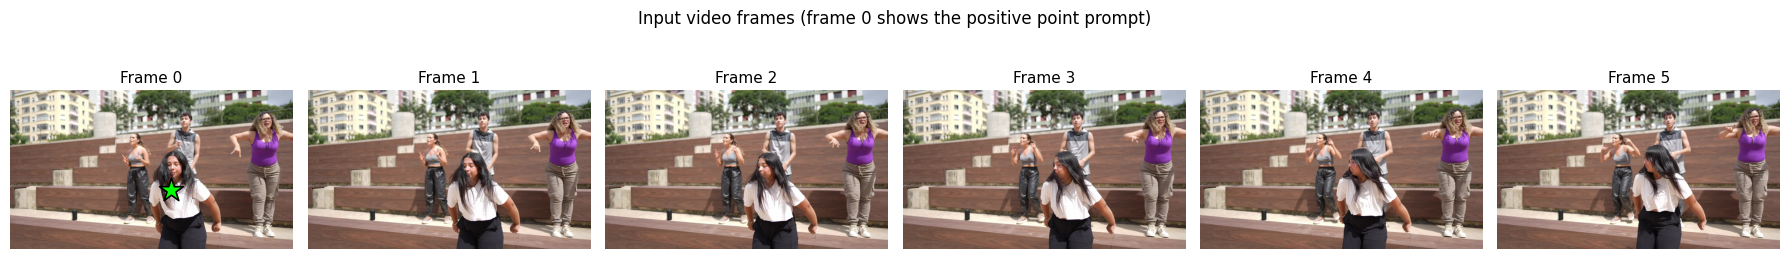

In [4]:
# === Show the input frames and the frame-0 prompt point (official-demo style) ===
import matplotlib.pyplot as plt

plt.rcParams["axes.titlesize"] = 11

fig, axes = plt.subplots(1, N_FRAMES, figsize=(3 * N_FRAMES, 3))
for i, (ax, frame) in enumerate(zip(axes, frames)):
    ax.imshow(np.asarray(frame))
    ax.set_title(f"Frame {i}")
    ax.axis("off")
    if i == 0:
        ax.scatter(
            [PROMPT_XY[0]],
            [PROMPT_XY[1]],
            c="lime",
            marker="*",
            s=320,
            edgecolors="black",
            linewidths=1.2,
            zorder=5,
        )
fig.suptitle("Input video frames (frame 0 shows the positive point prompt)")
plt.tight_layout()
plt.show()

In [5]:
# === Reference oracle: official PyTorch tracker (Sam3TrackerPredictor, CUDA bf16) ===
# Mirrors tools/run_pytorch_video.py: builds the tracker, loads the official weights,
# adds a point prompt on frame 0, and propagates with propagate_preflight=True.
# Device/dtype are taken from the config cell (explicit, logged — no implicit change).
import tempfile
import time

import torch

tools_path = str(REPO_ROOT / "tools")
if tools_path not in sys.path:
    sys.path.insert(0, tools_path)
from run_pytorch_video import _load_tracker  # noqa: E402  (reuse the proven loader)


class _NbLogger:
    """Minimal logger shim so we can reuse run_pytorch_video._load_tracker."""

    def info(self, msg, *a):
        print(_redact_text(msg % a if a else msg))

    warning = info
    error = info


def generate_pytorch_oracle(frames, prompt_norm, label, device, dtype_name):
    """Run the official tracker on the frames and return (masks_288, scores).

    masks_288: list of (288, 288) bool low-res masks (>0); scores: object_score_logits.
    """
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError(
            "ORACLE_DEVICE='cuda' but CUDA is unavailable. Set ORACLE_DEVICE = 'cpu' "
            "in the configuration cell to run the oracle on CPU (slow), or run on a CUDA machine."
        )
    print(
        f"Oracle device={device} dtype={dtype_name} (autocast enters in Sam3TrackerPredictor.__init__)"
    )
    tracker = _load_tracker(CHECKPOINT, _NbLogger())

    masks_288, scores = [], []
    with tempfile.TemporaryDirectory() as tmp:
        vdir = Path(tmp) / "frames"
        vdir.mkdir(parents=True)
        for i, f in enumerate(frames):
            f.save(vdir / f"{i:06d}.jpg", quality=95)
        with torch.inference_mode():
            state = tracker.init_state(
                video_path=str(vdir),
                video_height=IMG_H,
                video_width=IMG_W,
                offload_video_to_cpu=True,
            )
            tracker.add_new_points_or_box(
                inference_state=state,
                frame_idx=0,
                obj_id=1,
                points=[[prompt_norm[0], prompt_norm[1]]],
                labels=[label],
            )
            t0 = time.time()
            for _fidx, _ids, low_res_masks, _vmasks, obj_scores in tracker.propagate_in_video(
                inference_state=state,
                start_frame_idx=0,
                max_frame_num_to_track=state["num_frames"],
                reverse=False,
                propagate_preflight=True,
            ):
                lrm = low_res_masks.cpu().float()
                masks_288.append((lrm > 0).squeeze(1).numpy()[0])  # (288, 288) bool
                sc = obj_scores.cpu().float().numpy().reshape(-1)
                scores.append(float(sc[0]))
            print(f"Oracle propagated {len(masks_288)} frames in {time.time() - t0:.1f}s")
    del tracker
    import gc

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return masks_288, scores


oracle_masks, oracle_scores = generate_pytorch_oracle(
    frames, prompt_norm, PROMPT_LABEL, ORACLE_DEVICE, ORACLE_DTYPE
)
print("Oracle scores:", [f"{s:.3f}" for s in oracle_scores])

Oracle device=cuda dtype=bfloat16 (autocast enters in Sam3TrackerPredictor.__init__)
Building Sam3TrackerPredictor with ViT backbone ...
Tracker structure built in 17.9 s
Loading checkpoint from <repo>/models/sam3.pt ...
Mapped 309 tracker keys + 759 backbone keys from checkpoint
Unexpected keys in tracker ckpt: 295 keys (first 5: ['backbone.language_backbone.encoder.positional_embedding', 'backbone.language_backbone.encoder.text_projection', 'backbone.language_backbone.encoder.token_embedding.weight', 'backbone.language_backbone.encoder.transformer.resblocks.0.attn.in_proj_weight', 'backbone.language_backbone.encoder.transformer.resblocks.0.attn.in_proj_bias'])
Checkpoint loaded in 8.3 s (missing=0, unexpected=295)
Converting tracker weights to bfloat16 to reduce VRAM footprint ...
Moving tracker to CUDA ...
Tracker on CUDA in 1.4 s (GPU mem: 1.1 GiB used)
Tracker ready (device=cuda:0) in 27.6 s total


propagate in video: 100%|██████████| 6/6 [00:16<00:00,  2.74s/it]


Oracle propagated 6 frames in 16.5s
Oracle scores: ['21.500', '12.062', '11.688', '12.250', '12.000', '11.500']


In [6]:
# === ONNX orchestrator: full memory-bank tracking over the committed ONNX modules ===
# CPUExecutionProvider (explicit). The orchestrator imports onnxruntime lazily; no torch.
from sam3_onnx_equiv import VideoOrchestrator

orch = VideoOrchestrator(onnx_dir=ONNX_DIR, constants_dir=CONSTANTS_DIR, providers=ONNX_PROVIDERS)

point_coords_norm = np.array([[[prompt_norm[0], prompt_norm[1]]]], dtype=np.float32)
point_labels = np.array([[PROMPT_LABEL]], dtype=np.int32)

t0 = time.time()
onnx_result = orch.run_clip(
    frames_pil=frames,
    frame0_point_coords_norm=point_coords_norm,
    frame0_point_labels=point_labels,
    use_memory=True,
)
print(f"ONNX tracking done in {time.time() - t0:.1f}s")
print("memory_attention invocations:", onnx_result["memory_attention_invoke_count"])
print("obj ids per frame             :", onnx_result["obj_ids"])
print("ONNX scores                   :", [f"{s:.3f}" for s in onnx_result["scores"]])

onnx_masks = onnx_result["masks"]  # list of (288, 288) bool
assert len(onnx_masks) == len(oracle_masks) == N_FRAMES

ONNX tracking done in 669.6s
memory_attention invocations: 5
obj ids per frame             : [1, 1, 1, 1, 1, 1]
ONNX scores                   : ['21.338', '11.962', '11.759', '12.185', '12.033', '11.308']


In [7]:
# === Per-frame mask IoU: ONNX vs official PyTorch ===
def mask_iou(a: np.ndarray, b: np.ndarray) -> float:
    a, b = a.astype(bool), b.astype(bool)
    union = (a | b).sum()
    return 1.0 if union == 0 else float((a & b).sum()) / float(union)


ious, score_rel = [], []
print(f"{'frame':>5} | {'IoU':>7} | {'onnx_score':>10} | {'oracle_score':>12} | {'rel_diff':>8}")
print("-" * 60)
for i in range(N_FRAMES):
    iou = mask_iou(onnx_masks[i], oracle_masks[i])
    os_, cs = oracle_scores[i], onnx_result["scores"][i]
    rel = abs(cs - os_) / max(abs(os_), 1e-8)
    ious.append(iou)
    score_rel.append(rel)
    print(f"{i:>5} | {iou:>7.4f} | {cs:>10.3f} | {os_:>12.3f} | {rel:>8.4f}")

min_iou = min(ious)
print("-" * 60)
print(f"min IoU = {min_iou:.4f}  (threshold {IOU_THRESHOLD:.2f})")
print(
    f"mem_attention invocations = {onnx_result['memory_attention_invoke_count']} (expected {N_FRAMES - 1})"
)

assert min_iou >= IOU_THRESHOLD, (
    f"per-frame IoU {min_iou:.4f} below threshold {IOU_THRESHOLD:.2f} — ONNX/PyTorch mismatch."
)
assert onnx_result["memory_attention_invoke_count"] == N_FRAMES - 1, (
    "memory_attention must run once per propagated frame (memory tracking, not mask-prompt)."
)
print("\nPASS: every frame has IoU >= threshold and memory attention ran each frame.")

frame |     IoU | onnx_score | oracle_score | rel_diff
------------------------------------------------------------
    0 |  0.9930 |     21.338 |       21.500 |   0.0075
    1 |  0.9918 |     11.962 |       12.062 |   0.0084
    2 |  0.9574 |     11.759 |       11.688 |   0.0061
    3 |  0.9926 |     12.185 |       12.250 |   0.0053
    4 |  0.9924 |     12.033 |       12.000 |   0.0028
    5 |  0.9941 |     11.308 |       11.500 |   0.0167
------------------------------------------------------------
min IoU = 0.9574  (threshold 0.90)
mem_attention invocations = 5 (expected 5)

PASS: every frame has IoU >= threshold and memory attention ran each frame.


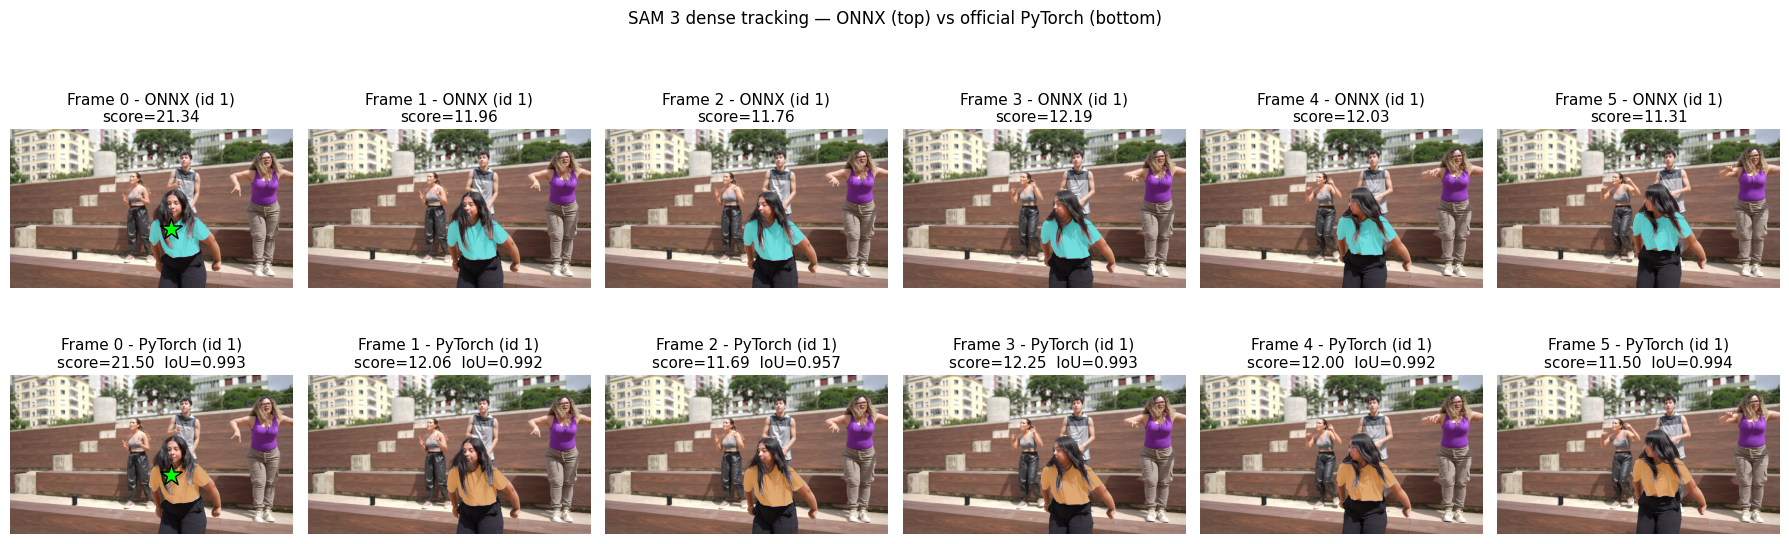

In [8]:
# === Per-frame mask overlay (official-demo style): ONNX (top) vs PyTorch (bottom) ===
def overlay_mask(ax, frame_img, mask_288, color, title):
    """Alpha-blend a 288x288 mask over the full-res frame, mirroring the official demo."""
    img = np.asarray(frame_img)
    h, w = img.shape[:2]
    # Upsample the low-res mask to the frame size (nearest — keeps a hard boundary).
    m = (
        np.asarray(Image.fromarray(mask_288.astype(np.uint8) * 255).resize((w, h), Image.NEAREST))
        > 127
    )
    ax.imshow(img)
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    overlay[m] = color
    ax.imshow(overlay)
    ax.set_title(title)
    ax.axis("off")


ONNX_COLOR = (0.0, 0.78, 0.78, 0.55)  # teal — track id 1
ORACLE_COLOR = (0.78, 0.39, 0.0, 0.55)  # orange — track id 1

fig, axes = plt.subplots(2, N_FRAMES, figsize=(3 * N_FRAMES, 6))
for i in range(N_FRAMES):
    overlay_mask(
        axes[0, i],
        frames[i],
        onnx_masks[i],
        ONNX_COLOR,
        f"Frame {i} - ONNX (id 1)\nscore={onnx_result['scores'][i]:.2f}",
    )
    overlay_mask(
        axes[1, i],
        frames[i],
        oracle_masks[i],
        ORACLE_COLOR,
        f"Frame {i} - PyTorch (id 1)\nscore={oracle_scores[i]:.2f}  IoU={ious[i]:.3f}",
    )
    if i == 0:
        for r in (0, 1):
            axes[r, i].scatter(
                [PROMPT_XY[0]],
                [PROMPT_XY[1]],
                c="lime",
                marker="*",
                s=260,
                edgecolors="black",
                linewidths=1.0,
                zorder=5,
            )
fig.suptitle("SAM 3 dense tracking — ONNX (top) vs official PyTorch (bottom)", y=1.01)
plt.tight_layout()
plt.show()

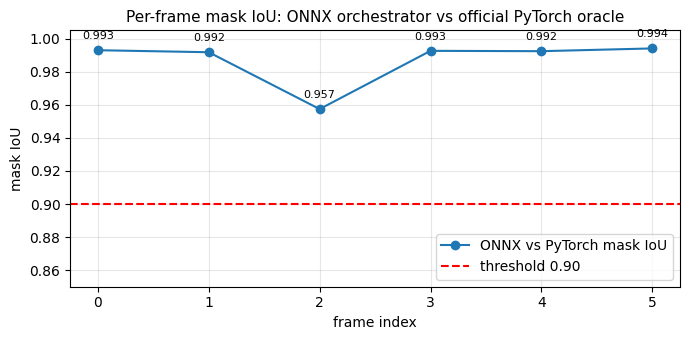

In [9]:
# === Per-frame IoU plot ===
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(N_FRAMES), ious, "o-", color="#1f77b4", label="ONNX vs PyTorch mask IoU")
ax.axhline(IOU_THRESHOLD, color="red", linestyle="--", label=f"threshold {IOU_THRESHOLD:.2f}")
ax.set_ylim(min(0.85, min(ious) - 0.02), 1.005)
ax.set_xlabel("frame index")
ax.set_ylabel("mask IoU")
ax.set_title("Per-frame mask IoU: ONNX orchestrator vs official PyTorch oracle")
ax.set_xticks(range(N_FRAMES))
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
for i, v in enumerate(ious):
    ax.annotate(
        f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8
    )
plt.tight_layout()
plt.show()

## Summary

- **Input**: the official SAM 3 sample video (`assets/videos/0001`), first 6 frames,
  prompted with a single positive point on frame 0 (front dancer).
- **ONNX path**: `VideoOrchestrator` (image_encoder_tracker + memory_attention_dynamic_k{N}
  + decode_head + memory_encoder + a Python memory bank), CPUExecutionProvider.
- **Reference**: official `Sam3TrackerPredictor` (CUDA bf16), the same code path as
  `tools/run_pytorch_video.py`.
- **Result**: the per-frame mask IoU is shown in the table/plot above and the assertions
  enforce **IoU >= 0.90** on every frame, with `memory_attention` invoked once per
  propagated frame — i.e. genuine memory-bank video tracking, reproduced through ONNX.

This is the same processing and visualisation flow as the official
`sam3_video_predictor_example.ipynb`, applied to the committed ONNX artifacts.
